# BrushCue Example: Swirl

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/swirl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/swirl

In [ ]:
!pip install brushcue

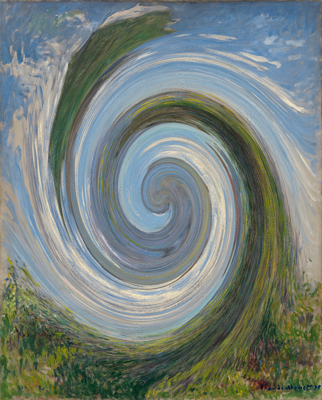

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let center = vec2<f32>(0.5, 0.5);\nlet dims = vec2<f32>(textureDimensions(input_texture, 0));\nlet uv = vec2<f32>(position) / dims;\nlet delta = uv - center;\nlet distance = length(delta);\nlet angle = atan2(delta.y, delta.x);\nlet radius = min(0.5, distance * 1.5);\nlet normalized_distance = distance / 0.5;\nlet falloff = max(0.0, 1.0 - normalized_distance);\nlet swirl_amount = falloff * falloff * swirl_amount;\nlet new_angle = angle + swirl_amount;\nlet new_delta = distance * vec2<f32>(cos(new_angle), sin(new_angle));\nlet new_uv = center + new_delta;\nlet new_pos_f = new_uv * dims;\nlet new_pos = vec2<u32>(new_pos_f);\nif (new_uv.x < 0.0 || new_uv.x > 1.0 || new_uv.y < 0.0 || new_uv.y > 1.0) {\n    return vec4<f32>(0.0, 0.0, 0.0, 0.0);\n}\nlet next_pos = vec2<u32>(new_pos_f + 1.0);\nlet frac = fract(new_pos_f);\nlet sampled1 = textureLoad(input_texture, new_pos, 0);\nlet sampled2 = textureLoad(input_texture, vec2<u32>(next_pos.x, new_pos.y), 0);\nlet sampled3 = textureLoad(input_texture, vec2<u32>(new_pos.x, next_pos.y), 0);\nlet sampled4 = textureLoad(input_texture, next_pos, 0);\nlet interpolated = mix(\n    mix(sampled1, sampled2, frac.x),\n    mix(sampled3, sampled4, frac.x),\n    frac.y\n);\nreturn interpolated;")
string_constant_3 = brushcue.string_constant("")
get_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
dictionary_create_6 = brushcue.dictionary_create()
string_constant_7 = brushcue.string_constant("swirl_amount")
float_constant_8 = brushcue.float_constant(10.0)
swirl_amount_9 = brushcue.float_passthrough(float_constant_8)
float_add_to_dictionary_10 = brushcue.float_add_to_dictionary(dictionary_create_6, string_constant_7, swirl_amount_9)
swirl_shader_11 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, get_color_profile_4, get_color_profile_4, float_add_to_dictionary_10, bool_constant_5)

ctx = brushcue.Context()
result = swirl_shader_11.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
